# Installing the complete stack

In [40]:
!pip install -qU langchain-huggingface langgraph google-search-results streamlit python-docx pyngrok

# Initializing LLM Model and Setting up Environment

In [41]:
from google.colab import userdata
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
import os

In [42]:
os.environ["HUGGINGFACEHUB_API_TOKEN"] = userdata.get('HUGGINGFACEHUB_API_TOKEN')
os.environ["SERPAPI_API_KEY"] = userdata.get('SERPAPI_API_KEY')

def get_model():
    llm = HuggingFaceEndpoint(
        repo_id="meta-llama/Llama-3.1-8B-Instruct",
        task="text-generation",
        max_new_tokens=2500,
        temperature=0.0,
    )
    return ChatHuggingFace(llm=llm)

model = get_model()

# Langgraph

In [43]:
import docx
import json
import re
from typing import TypedDict, List, Dict
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
from serpapi import GoogleSearch

## Defining the AgentState

In [44]:
class AgentState(TypedDict):
    file_path: str
    current_text: str
    feedback_history: List[Dict]
    blacklist: List[str]
    filters: dict
    queries: List[str]
    raw_results: List[dict]
    valid_papers: List[dict]
    final_synthesis: str
    bibliography: str
    critic_report: str
    loop_count: int

## Utility Functions for Reading the Word Document and formating Citations

In [45]:
def read_word_doc(path):
    try:
        doc = docx.Document(path)
        return "\n".join([p.text for p in doc.paragraphs])
    except:
        return ""

def format_citation_label(paper, style="APA", index=1):
    info = paper.get("publication_info", {}).get("summary", "Unknown")

    author_chunk = info.split("-")[0].strip()
    author = author_chunk.split(" ")[-1] if author_chunk else "Unknown"

    year_match = re.search(r'\b(19|20)\d{2}\b', info)
    year = year_match.group(0) if year_match else "n.d."

    if style == "IEEE": return f"[{index}]"
    if style == "MLA": return f"({author})"
    if style == "APA": return f"({author}, {year})"
    return f"({author}, {year})"

## Constructing Langgraph Nodes

### Observer Node

In [46]:
def observer_node(state: AgentState):
    """Refines strategy based on specific criteria failures in flagged papers."""
    text = read_word_doc(state['file_path'])

    failures = ""
    if state['feedback_history']:
        failures = "\nPREVIOUS FAILURES TO CORRECT:\n"
        for entry in state['feedback_history']:
            failures += f"- Source '{entry['title']}' rejected because: {', '.join(entry['reasons'])}\n"

    prompt = ChatPromptTemplate.from_template(
        "Draft: '{text}'{failures}\n"
        "Task: Create 10 search queries. Avoid the years or publishers that previously failed. "
        "Strictly target papers that meet the user's constraints. Return queries only."
    )
    res = (prompt | model).invoke({"text": text[-1000:], "failures": failures})
    queries = [q.strip() for q in res.content.split('\n') if len(q) > 5][:10]
    return {"current_text": text, "queries": queries}


### Researcher Node

In [47]:
def researcher_node(state: AgentState):
    """Executes searches strictly across Google Scholar."""
    filters = state['filters']
    results = []

    query_ext = ""
    if filters['publishers']:
        pub_or = " OR ".join([f"source:{p}" for p in filters['publishers']])
        query_ext += f" ({pub_or})"

    # Pure Google Scholar Search
    for q in state['queries']:
        search = GoogleSearch({
            "engine": "google_scholar", "q": q + query_ext,
            "as_ylo": 2020, "api_key": os.environ["SERPAPI_API_KEY"]
        })
        results.extend(search.get_dict().get("organic_results", []))

    return {"raw_results": results}

### Auditor Node

In [48]:
def auditor_node(state: AgentState):
    """Audit: Hard-blocks blacklisted URLs and requires open Google Scholar resources."""
    valid = []
    seen = set(state.get('blacklist', []))

    for p in state['raw_results']:
        link = p.get("link", "").lower()

        if link in seen:
            continue

        # Strictly requires a free PDF/HTML resource link from Google Scholar
        is_open = "resources" in p

        if is_open and link not in seen:
            valid.append(p)
            seen.add(link)

        if len(valid) >= 10:
            break

    return {"valid_papers": valid}

### Drafter Node

In [49]:
def drafter_node(state: AgentState):
    style = state['filters']['style']
    papers = state['valid_papers']

    ref_context = ""
    bib_list = ""
    for i, p in enumerate(papers):
        label = format_citation_label(p, style, i+1)
        ref_context += f"Source {i+1}: {p['title']} | Snippet: {p['snippet']} | Use Label: {label}\n"
        bib_list += f"{label} {p['title']}. [URL: {p['link']}]\n"

    prompt = ChatPromptTemplate.from_template(
        "Draft: {text}\nEvidence:\n{evidence}\n"
        "Task: 1. Rewrite paragraph with {style} citations.\n"
        "2. Provide Strategic Usage for each. Ensure tone is human, not robotic."
    )
    res = (prompt | model).invoke({"text": state['current_text'][-800:], "evidence": ref_context, "style": style})
    return {"final_synthesis": res.content, "bibliography": bib_list}

### Critic Node

In [50]:
def critic_node(state: AgentState):
    loop_count = state.get("loop_count", 0)

    if loop_count >= 3:
        return {"critic_report": "PASS", "loop_count": loop_count}

    filters = state['filters']
    papers = state['valid_papers']
    bib = state.get('bibliography', '')
    text = state.get('current_text', '')[-800:]

    sources_text = ""
    for i, p in enumerate(papers):
        sources_text += f"Source {i+1}:\nTitle: {p['title']}\nLink: {p['link']}\nSnippet: {p['snippet']}\n\n"

    prompt_template = """
    You are an uncompromising Academic Auditor. Evaluate these {num} sources against 6 strict constraints.

    Constraints:
    1. Not Relevant: Does the snippet fail to support the draft text?
    2. Wrong Year Range: Does the publication year fall outside the inclusive range of 2020 to 2025?
    3. Not Open Source: Does it lack an open access link, PDF, or seem paywalled?
    4. Fake / Not Citable: Does it look like a hallucinated or non-academic source?
    5. Wrong Publisher: If specified ({publishers}), is it from the wrong publisher?
    6. Wrong Citation Style: Is the bibliography NOT strictly formatted in {style} style?

    Draft Context:
    {text}

    Sources to Evaluate:
    {sources_text}

    Bibliography to Check (for constraint 6):
    {bib}

    You MUST output your evaluation strictly as a JSON object. Do not include markdown formatting or extra text outside the JSON.
    {{
        "status": "PASS", // Change to "FAIL" if ANY source fails ANY constraint
        "flags": [
            {{
                "title": "Exact Title of Source",
                "link": "Exact Link of Source",
                "reasons": ["Not Relevant", "Wrong Year Range", "Not Open Source", "Fake / Not Citable", "Wrong Publisher", "Wrong Citation Style"]
            }}
        ]
    }}
    """

    prompt = ChatPromptTemplate.from_template(prompt_template)
    res = (prompt | model).invoke({
        "num": len(papers),
        "publishers": filters['publishers'] if filters['publishers'] else "Any",
        "style": filters['style'],
        "text": text,
        "sources_text": sources_text,
        "bib": bib
    })

    try:
        content = res.content
        json_match = re.search(r'\{.*\}', content, re.DOTALL)
        parsed = json.loads(json_match.group(0)) if json_match else json.loads(content)

        if parsed.get("status") == "FAIL" and parsed.get("flags"):
            new_blacklist = state.get("blacklist", []) + [f["link"] for f in parsed["flags"]]
            return {
                "critic_report": "REVISE: Automated Agent Feedback",
                "feedback_history": parsed["flags"],
                "blacklist": list(set(new_blacklist)),
                "loop_count": loop_count + 1
            }
        else:
            return {"critic_report": "PASS", "loop_count": loop_count + 1}

    except Exception as e:
        print(f"Critic JSON parsing failed: {e}")
        return {"critic_report": "REVISE: Critic Output Malformed", "loop_count": loop_count + 1}


## Router

In [51]:
def router(state: AgentState):
    return END if "PASS" in state.get('critic_report', '') else "observer"

# Langraph Deployment

In [52]:
builder = StateGraph(AgentState)
builder.add_node("observer", observer_node)
builder.add_node("researcher", researcher_node)
builder.add_node("auditor", auditor_node)
builder.add_node("drafter", drafter_node)
builder.add_node("critic", critic_node)

builder.set_entry_point("observer")
builder.add_edge("observer", "researcher")
builder.add_edge("researcher", "auditor")
builder.add_edge("auditor", "drafter")
builder.add_edge("drafter", "critic")
builder.add_conditional_edges("critic", router)

graph = builder.compile()

### Visualizing the Nodes

In [53]:
from IPython.display import Image, display
from langchain_core.runnables.graph import CurveStyle, MermaidDrawMethod, NodeStyles

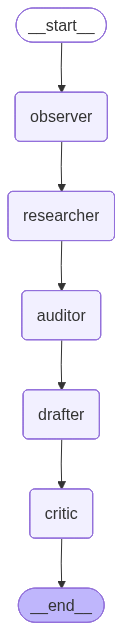

In [54]:
display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [55]:
test_result = graph.invoke({
    "file_path": "document.docx",
    "filters": {"style": "APA", "publishers": ["Elsevier"]},
    "feedback_history": [],
    "blacklist": [],
    "loop_count": 0
})

print("\n=== FINAL SYNTHESIS ===")
print(test_result.get('final_synthesis', 'No synthesis generated.'))

print("\n=== BIBLIOGRAPHY ===")
print(test_result.get('bibliography', 'No bibliography generated.'))

print(f"\nLoops executed: {test_result.get('loop_count')}")


=== FINAL SYNTHESIS ===
**Rewritten Paragraph:**

Telemedicine has become a staple in the healthcare industry, especially since the pandemic. This shift has been beneficial in various ways, such as allowing doctors to reach patients in remote areas and reducing hospital burdens (Fuady, 2024). However, there are concerns about the quality of care and the "digital divide" that prevents some patients, especially older adults or those with limited internet access, from accessing these services. According to research, addressing the payment and regulatory limitations, as well as the lack of awareness and digital skills, are significant barriers to telemedicine adoption (Smith, 2020). Furthermore, the effectiveness of telemedicine in managing conditions like cardiovascular disease is being studied, with promising results (Rahman, 2022). As we move forward, understanding the nuances of telemedicine adoption, such as the impact of digital divides and perceptual barriers (Phan, 2022), will be 